<a href="https://colab.research.google.com/github/EhsanGhasemi423/INFS-8368/blob/main/6_Neural_Networks_Part_1_(Regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Before building deep neural networks, we begin with shallow networks, where inputs connect directly to outputs. This lets us focus on core training concepts and introduces linear models such as linear and softmax regression, which are widely used and serve as important baselines for more complex architectures.


## Linear Regression

Regression is used to predict **continuous numerical values**, such as house prices, hospital length of stay, and retail demand. Unlike classification, which predicts categories, regression predicts numeric outcomes.

For example, a linear regression model can predict a house's **price** using features such as its **area** and **age**.

To train the model, we use a **training set**, where each row is an **example** (or **sample**). The value being predicted is the **label** (or **target**), while the input variables used for prediction are called **features**.

In [ ]:
!pip install -q d2l --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 3.7 MB/s eta 0:00:00


In [ ]:
%matplotlib inline
import math
import time
import numpy as np
import tensorflow as tf
from d2l import tensorflow as d2l

### Intro

Linear regression is one of the simplest and most widely used methods for predicting continuous numerical values. It is based on two key assumptions:

1. **Linear relationship:** The predicted value is computed as a weighted sum of the input features, where each feature contributes according to its importance.
2. **Random noise:** The observed values may differ from the predicted values due to random error (noise), which is often assumed to follow a Gaussian (normal) distribution.

Throughout this section:

- $n$ denotes the number of training examples.
- $\mathbf{x}^{(i)}$ denotes the $i$-th training example.
- $x_j^{(i)}$ denotes the $j$-th feature of the $i$-th example.
- $y^{(i)}$ denotes the corresponding target value.

## Linear Regression Model

A linear regression model predicts a target value as a weighted sum of the input features plus a bias (intercept):

$$
\hat{y} = w_1x_1 + w_2x_2 + \cdots + w_dx_d + b
$$

where:

- $\hat{y}$ is the predicted value.
- $x_1, x_2, \ldots, x_d$ are the input features.
- $w_1, w_2, \ldots, w_d$ are the **weights**, which determine the importance of each feature.
- $b$ is the **bias** (or intercept), which shifts the prediction up or down.

Using vector notation, the model can be written more compactly as:

$$
\hat{y} = \mathbf{w}^\top \mathbf{x} + b
$$

The objective of linear regression is to learn the values of the weights $\mathbf{w}$ and bias $b$ that produce predictions as close as possible to the true target values.

In practice, predictions are not exact because of measurement errors and other unobserved factors. Therefore, the observed target can be written as

$$
y = \mathbf{w}^\top \mathbf{x} + b + \varepsilon,
$$

where $\varepsilon$ represents random error (noise).

Before training the model, we need:

1. A **loss function** to measure prediction error.
2. An **optimization algorithm** to adjust the weights and bias to minimize that error.

## Loss Function

A **loss function** measures how well a model's predictions match the true target values. A smaller loss indicates better predictions, while a loss of **0** means the predictions are perfect.

For linear regression, the most common loss function is the **Mean Squared Error (MSE)**. For a single training example, the squared error is

$$
l^{(i)} = \frac{1}{2}\left(\hat{y}^{(i)} - y^{(i)}\right)^2,
$$

where:

- $\hat{y}^{(i)}$ is the predicted value.
- $y^{(i)}$ is the true value.

The error is **squared**, so larger prediction errors receive a much larger penalty than smaller ones.

To evaluate the model on the entire training set, we compute the average loss:

$$
L(\mathbf{w}, b)=\frac{1}{n}\sum_{i=1}^{n} l^{(i)}.
$$

The goal of training is to find the weights $\mathbf{w}$ and bias $b$ that **minimize the average loss**.

> **Note:** Some textbooks define the squared error as
>
> $$
> l^{(i)}=\frac{1}{2}\left(\hat{y}^{(i)}-y^{(i)}\right)^2.
> $$
>
> The factor $\frac{1}{2}$ does **not** change the model or its predictions. It is included only to simplify the derivatives when deriving gradient descent, since the exponent 2 cancels with the factor $\frac{1}{2}$ during differentiation.

## Optimization Algorithm: Mini-Batch Stochastic Gradient Descent (Mini-Batch SGD)

After defining the loss function, the next step is to **minimize** it. To do this, we use an **optimization algorithm**, which updates the model parameters (weights and bias) to reduce the loss over time.

The most widely used optimization algorithm in deep learning is **Mini-Batch Stochastic Gradient Descent (Mini-Batch SGD)**. Instead of using the entire training dataset or a single example, Mini-Batch SGD updates the model parameters using a **small subset (mini-batch)** of the training data at each iteration. This provides a good balance between computational efficiency and stable learning.

There are three common variants of gradient descent:

- **Batch Gradient Descent:** Uses the entire training dataset to compute each update.
- **Stochastic Gradient Descent (SGD):** Uses one training example at a time.
- **Mini-Batch SGD:** Uses a small subset (mini-batch) of the training data for each update.

During each iteration, Mini-Batch SGD performs the following steps:

1. **Select a mini-batch** of training examples.
2. **Compute the predictions** using the current values of the weights and bias.
3. **Compute the average loss** on the mini-batch. The loss measures how far the predictions are from the true target values.
4. **Compute the gradients** of the loss with respect to the weights and bias. The gradients indicate how each parameter should be adjusted to reduce the loss.
5. **Update the model parameters** using the computed gradients.

The parameter updates are

$$
\mathbf{w} \leftarrow \mathbf{w} - \eta \frac{\partial L}{\partial \mathbf{w}},
$$

$$
b \leftarrow b - \eta \frac{\partial L}{\partial b},
$$

where:

- $\mathbf{w}$ is the vector of model weights.
- $b$ is the bias (intercept).
- $L$ is the average loss over the mini-batch.
- $\frac{\partial L}{\partial \mathbf{w}}$ is the gradient of the loss with respect to the weights.
- $\frac{\partial L}{\partial b}$ is the gradient of the loss with respect to the bias.
- $\eta$ is the **learning rate**, which controls the size of each update.

The update rule subtracts the gradient because the gradient points in the direction of **greatest increase** of the loss. By moving in the opposite direction, the algorithm gradually reduces the loss and improves the model's predictions.

Each gradient tells us how the loss changes when a model parameter changes. If the gradient is positive, we decrease the parameter. If the gradient is negative, we increase the parameter. By repeating these updates, the loss gradually decreases.



**Key Takeaways:**

The **loss function** tells us how well the model is performing, but it does not indicate how to improve it. To determine how to update the model parameters, we compute the **gradient of the loss**. The gradient points in the direction of the greatest increase of the loss. Therefore, to reduce the loss, we update the model parameters by moving a small step in the opposite direction of the gradient.

The optimization algorithm used to update the model parameters is called **Gradient Descent**. Since the gradient points in the direction of the greatest increase of the loss, Gradient Descent updates the parameters by moving in the opposite direction of the gradient.

## Making Predictions

After training, the learned weights and bias are used to make predictions for new examples.

For a new input $\mathbf{x}$, the predicted value is

$$
\hat{y}=\mathbf{w}^\top\mathbf{x}+b.
$$

For example, if a linear regression model is trained to predict house prices, it can estimate the price of a new house based on features such as its area and age.

## Vectorization for Speed

When training machine learning models, we often perform the same operation on many training examples at once. Instead of processing one element at a time with Python loops, TensorFlow uses **vectorized operations**, which apply an operation to an entire vector or matrix in a single step.

Vectorized operations are much faster because they use highly optimized linear algebra libraries and can take advantage of parallel hardware such as GPUs.

The following example compares two ways of adding two vectors:
- Using a Python `for` loop.
- Using TensorFlow's vectorized `+` operator.



First, we create two vectors of length 10,000, where every element is equal to 1. These vectors will be added using two different approaches: a Python `for` loop and TensorFlow's vectorized `+` operator.

In [ ]:
n = 10000
a = tf.ones(n)
b = tf.ones(n)

In [ ]:
c = tf.Variable(tf.zeros(n))
t = time.time()
for i in range(n):
    c[i].assign(a[i] + b[i])
f'{time.time() - t:.5f} sec'

'12.03415 sec'

In [ ]:
t

1785009873.5442114

In [ ]:
t = time.time()
d = a + b
f'{time.time() - t:.5f} sec'

'0.00253 sec'

## Linear Regression as a Neural Network

Linear regression can be viewed as the simplest type of neural network. Each input feature corresponds to an **input neuron**, and every input is connected directly to a single **output neuron**. Each connection has an associated **weight**, and the output neuron also has a **bias**.

Because there is only one layer of trainable connections between the inputs and the output, linear regression is called a **single-layer neural network** (or a **single-layer fully connected network**).


![Linear regression as a single-layer neural network](images/linear_regression_nn.png)
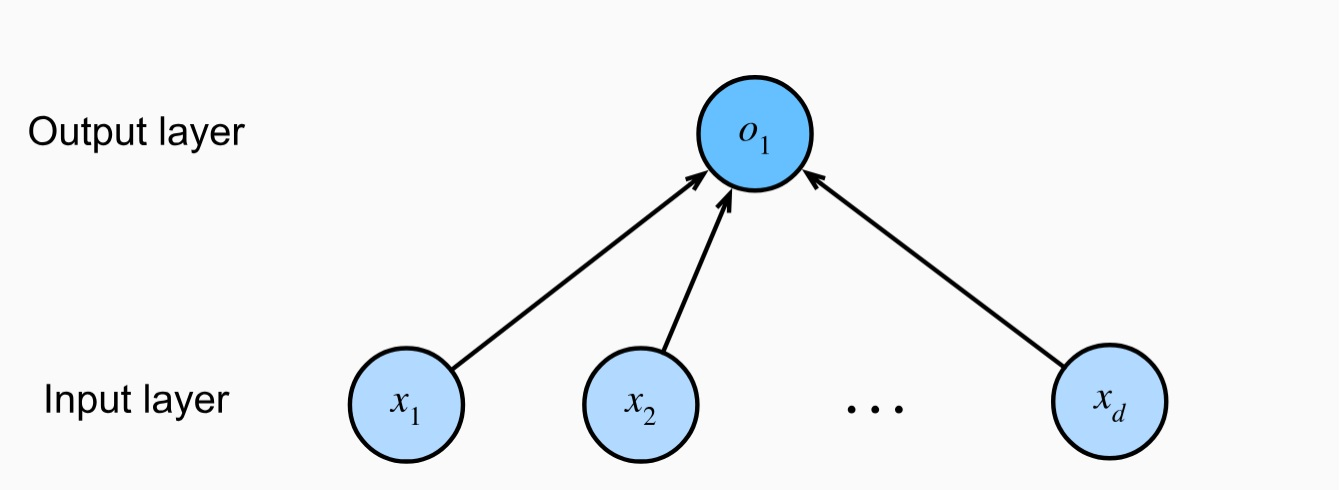


## Biological Inspiration

Artificial neural networks are inspired by the structure of biological neurons, although they are greatly simplified.

A biological neuron receives signals from other neurons through its **dendrites**. These signals are combined in the **cell body**, and if the combined signal is strong enough, the neuron sends an output signal through its **axon** to other neurons.

Similarly, an artificial neuron receives multiple inputs, multiplies each input by a corresponding weight, adds a bias, and optionally applies an activation function before producing an output.

The figure below compares a biological neuron with an artificial neuron.

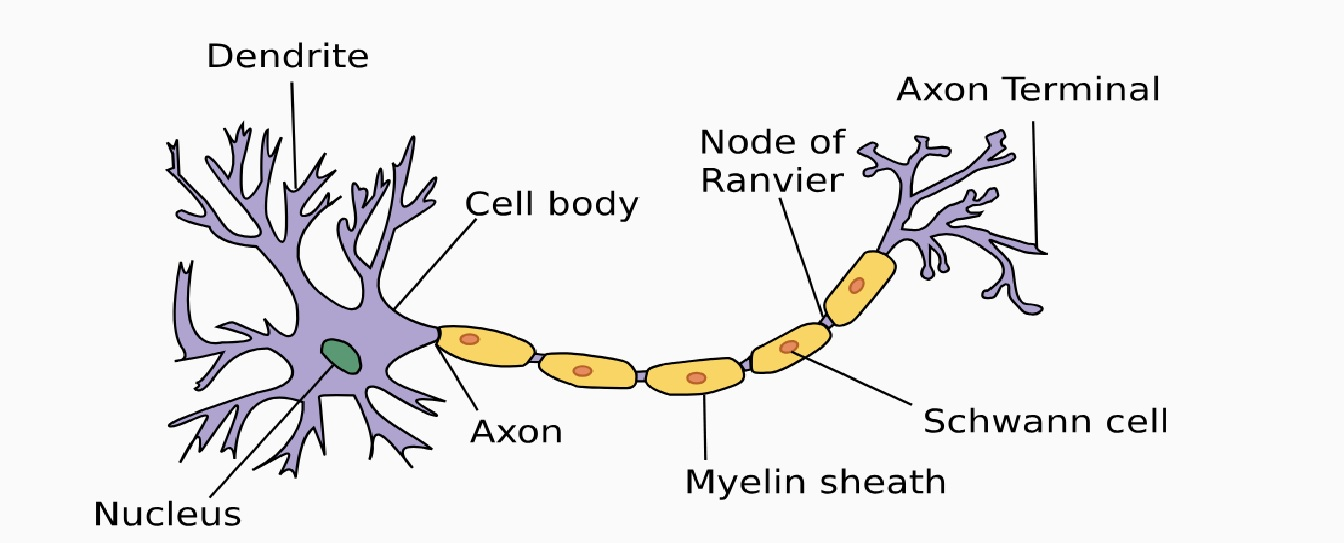


## Summary

We introduced **linear regression**, one of the simplest and most widely used machine learning models for predicting continuous numerical values.

We learned how a linear regression model:
- predicts a target value using a weighted sum of the input features and a bias,
- measures prediction error using the squared loss,
- learns its parameters by minimizing the loss with Mini-Batch Stochastic Gradient Descent (Mini-Batch SGD), and
- can be viewed as a single-layer fully connected neural network.

Although linear regression is a simple model, it introduces many of the core ideas used throughout deep learning, including model parameters, loss functions, optimization, and making predictions on unseen data.